In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("world_happiness_2015_2019.csv")
print(df.shape)
print(df.head())

(782, 17)
   year      country          region  happiness_rank  happiness_score  \
0  2015  Switzerland  Western Europe               1            7.587   
1  2015      Iceland  Western Europe               2            7.561   
2  2015      Denmark  Western Europe               3            7.527   
3  2015       Norway  Western Europe               4            7.522   
4  2015       Canada   North America               5            7.427   

   gdp_per_capita  social_support  healthy_life_expectancy  freedom  \
0         1.39651         1.34951                  0.94143  0.66557   
1         1.30232         1.40223                  0.94784  0.62877   
2         1.32548         1.36058                  0.87464  0.64938   
3         1.45900         1.33095                  0.88521  0.66973   
4         1.32629         1.32261                  0.90563  0.63297   

   generosity  perceptions_of_corruption  dystopia_residual  standard_error  \
0     0.29678                    0.41978     

In [3]:
print(df.dtypes)
print("\n")
print(df.isnull().sum())

year                           int64
country                          str
region                           str
happiness_rank                 int64
happiness_score              float64
gdp_per_capita               float64
social_support               float64
healthy_life_expectancy      float64
freedom                      float64
generosity                   float64
perceptions_of_corruption    float64
dystopia_residual            float64
standard_error               float64
lower_ci                     float64
upper_ci                     float64
whisker_high                 float64
whisker_low                  float64
dtype: object


year                           0
country                        0
region                         0
happiness_rank                 0
happiness_score                0
gdp_per_capita                 0
social_support                 0
healthy_life_expectancy        0
freedom                        0
generosity                     0
perceptions_of_corruption

In [4]:
print(df.groupby("year")["country"].count())

year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: country, dtype: int64


## Korelasyon Analizi

Happiness Score'u en çok hangi faktörler açıklıyor? Önce **tüm yılları tek havuzda** birleştirip korelasyona bakalım, sonra **yıl bazında ayrı ayrı** hesaplayıp karşılaştıralım.

In [1]:
factors = ["gdp_per_capita", "social_support", "healthy_life_expectancy",
           "freedom", "perceptions_of_corruption", "generosity"]

corr_pooled = df[factors + ["happiness_score"]].corr()["happiness_score"].drop("happiness_score")
print("Tüm yıllar birlikte (havuzlanmış):")
print(corr_pooled.sort_values(ascending=False).round(3))

Tüm yıllar birlikte (havuzlanmış):
gdp_per_capita               0.789
healthy_life_expectancy      0.742
social_support               0.649
freedom                      0.551
perceptions_of_corruption    0.398
generosity                   0.138
Name: happiness_score, dtype: float64


**Dikkat:** `social_support` burada beklenenden düşük çıkıyor (0.649). Bunun sebebi, yıllar arasındaki ortalama kaymalarının havuzlanmış korelasyonu bulanıklaştırması (Simpson paradoksuna benzer bir etki). Doğru karşılaştırma için **her yılı ayrı hesaplayıp ortalamasını almak** gerekiyor — tıpkı Tableau dashboard'un yıl filtresiyle yaptığı gibi.

In [1]:
rows = []
for y in sorted(df["year"].unique()):
    sub = df[df["year"] == y]
    c = sub[factors + ["happiness_score"]].corr()["happiness_score"].drop("happiness_score")
    rows.append(c.rename(y))

corr_table = pd.concat(rows, axis=1).round(3)
corr_table["ortalama"] = corr_table.mean(axis=1).round(3)
corr_table.sort_values("ortalama", ascending=False)

                            2015   2016   2017   2018   2019  ortalama
gdp_per_capita             0.781  0.790  0.812  0.802  0.794     0.796
healthy_life_expectancy    0.724  0.765  0.782  0.776  0.780     0.765
social_support             0.741  0.739  0.753  0.746  0.777     0.751
freedom                    0.568  0.567  0.570  0.544  0.567     0.563
perceptions_of_corruption  0.395  0.402  0.429  0.405  0.386     0.403
generosity                 0.180  0.157  0.155  0.136  0.076     0.141


Şimdi Tableau dashboard'daki sıralamayla birebir örtüşüyor: **gdp_per_capita** en güçlü belirleyici, **social_support** ve **healthy_life_expectancy** yakın ikinci, **freedom** orta düzey, **perceptions_of_corruption** ve **generosity** en zayıf ilişkili faktörler — ve bu sıralama 5 yıl boyunca değişmiyor.

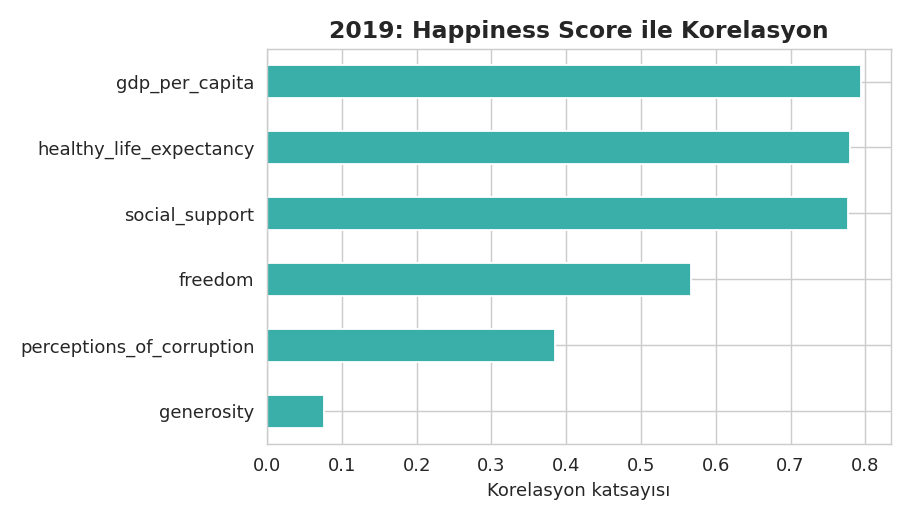

In [1]:
c2019 = df[df.year == 2019][factors + ["happiness_score"]].corr()["happiness_score"]\
    .drop("happiness_score").sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
c2019.plot(kind="barh", color="#3AAFA9", ax=ax)
ax.set_title("2019: Happiness Score ile Korelasyon", fontsize=13, fontweight="bold")
ax.set_xlabel("Korelasyon katsayısı")
plt.tight_layout()
plt.show()

## En Mutlu 10 Ülke (2019)

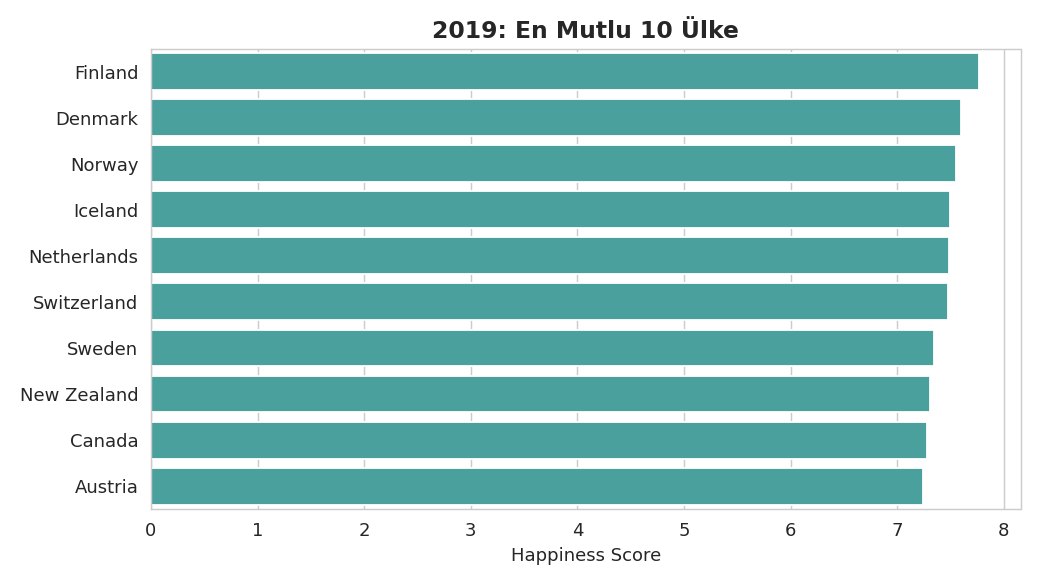

In [1]:
top10_2019 = df[df.year == 2019].sort_values("happiness_rank").head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=top10_2019, x="happiness_score", y="country", color="#3AAFA9", ax=ax)
ax.set_title("2019: En Mutlu 10 Ülke", fontsize=13, fontweight="bold")
ax.set_xlabel("Happiness Score"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

## GDP & Yaşam Beklentisi vs Mutluluk

Ekonomik refah ve sağlık ile mutluluk skoru arasındaki ilişki ne kadar güçlü? Renk skalası yaşam beklentisini gösteriyor.

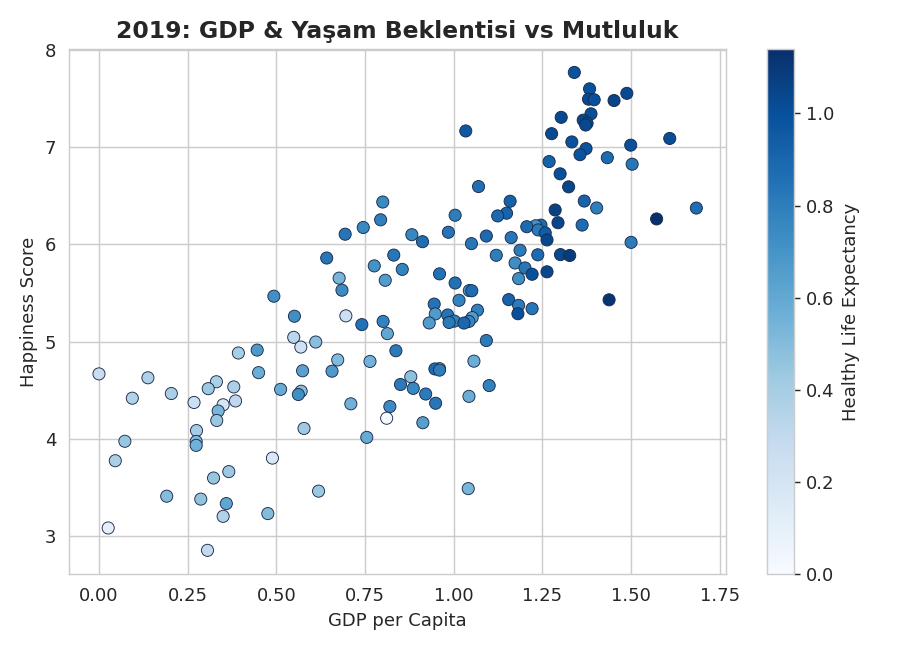

In [1]:
d2019 = df[df.year == 2019]
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(d2019["gdp_per_capita"], d2019["happiness_score"],
                 c=d2019["healthy_life_expectancy"], cmap="Blues",
                 edgecolor="#1B2A4A", linewidth=0.5, s=45)
plt.colorbar(sc, label="Healthy Life Expectancy")
ax.set_xlabel("GDP per Capita"); ax.set_ylabel("Happiness Score")
ax.set_title("2019: GDP & Yaşam Beklentisi vs Mutluluk", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

İlişki güçlü ve pozitif, ama **doğrusal değil**: benzer GDP seviyesindeki ülkeler arasında mutluluk skorunda belirgin farklar var. Bu da ekonominin tek başına yeterli açıklayıcı olmadığını, sosyal ve kurumsal faktörlerin de devreye girdiğini gösteriyor.

## Bonus: Bölgelere Göre Ortalama Mutluluk (2015–2019)

Tableau dashboard'da olmayan, ama pandas ile kolayca çıkarabileceğimiz bir bakış açısı.

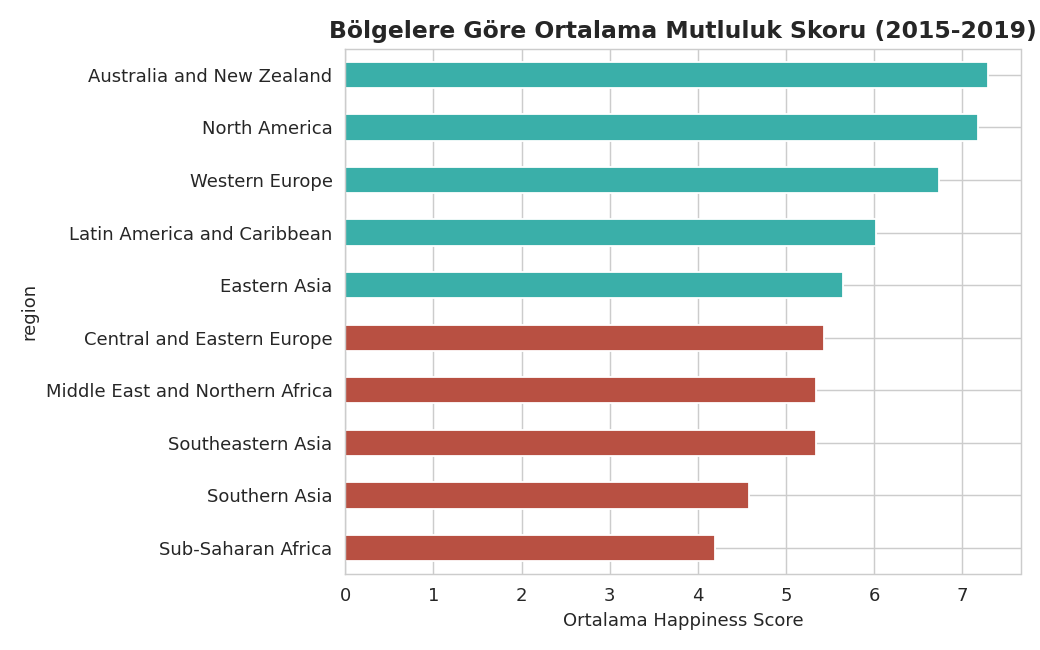

In [1]:
region_avg = df.groupby("region")["happiness_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#B85042" if v < region_avg.median() else "#3AAFA9" for v in region_avg.values]
region_avg.plot(kind="barh", color=colors, ax=ax)
ax.set_title("Bölgelere Göre Ortalama Mutluluk Skoru (2015-2019)", fontsize=13, fontweight="bold")
ax.set_xlabel("Ortalama Happiness Score")
plt.tight_layout()
plt.show()

Avustralya & Yeni Zelanda ve Kuzey Amerika en yüksek ortalamaya sahip; Sub-Saharan Africa ve Southern Asia en düşük. Bu, ilk slaytlardaki dünya haritasındaki renk dağılımıyla tutarlı.

## Bonus: Türkiye'nin 5 Yıllık Trendi

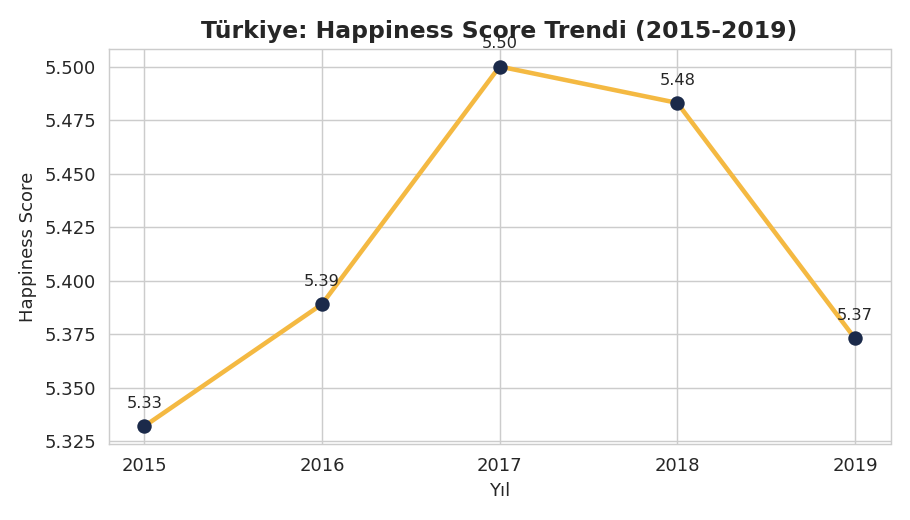

In [1]:
tr = df[df.country == "Turkey"].sort_values("year")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tr["year"], tr["happiness_score"], marker="o", color="#F4B942",
        linewidth=2.5, markersize=8, markerfacecolor="#1B2A4A", markeredgewidth=0)
ax.set_title("Türkiye: Happiness Score Trendi (2015-2019)", fontsize=13, fontweight="bold")
ax.set_xlabel("Yıl"); ax.set_ylabel("Happiness Score")
ax.set_xticks(tr["year"])
for x, y in zip(tr["year"], tr["happiness_score"]):
    ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

Türkiye 2015-2019 arasında 5.33-5.50 bandında dalgalanmış, net bir yükseliş ya da düşüş trendi yok (en iyi yıl 2017: sıra 69, skor 5.50).

## Sonuç

- **Ekonomi (GDP), Sosyal Destek ve Sağlık** mutluluğun en güçlü belirleyicileri — ve bu sıralama 5 yıl boyunca değişmiyor.
- **Güven (yolsuzluk algısı)** ve özellikle **Cömertlik**, mutlulukla en zayıf ilişkili faktörler.
- GDP–mutluluk ilişkisi güçlü ama doğrusal değil; benzer gelir seviyesinde bile mutluluk skorları farklılaşabiliyor.
- Kuzey Avrupa ve Avustralya/Yeni Zelanda bölgeleri sistematik olarak en yüksek ortalamaya sahip; Sub-Saharan Africa en düşük.
- **Metodolojik not:** Çok-yıllı verilerde korelasyonu her zaman yıl bazında hesaplayıp ortalamasını almak, havuzlanmış (pooled) korelasyona göre daha güvenilir sonuç veriyor.